# importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Data PreProcessing

Data Loading

In [3]:
housing_price = pd.read_csv('housing.csv')
housing_price.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [4]:
housing_price.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [5]:
#check for missing values
print("Missing values:\n", housing_price.isnull().sum())

Missing values:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [6]:
'''Fill the missing value with median value of total_bedrooms colums'''
median_value = housing_price['total_bedrooms'].median()
housing_price['total_bedrooms'] = housing_price['total_bedrooms'].fillna(median_value)
print(housing_price['total_bedrooms'])
print("NUll values:", housing_price['total_bedrooms'].isnull().sum())

0         129.0
1        1106.0
2         190.0
3         235.0
4         280.0
          ...  
20635     374.0
20636     150.0
20637     485.0
20638     409.0
20639     616.0
Name: total_bedrooms, Length: 20640, dtype: float64
NUll values: 0


In [7]:
print(housing_price['ocean_proximity'].unique())

<ArrowStringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str


# Checking Outliers

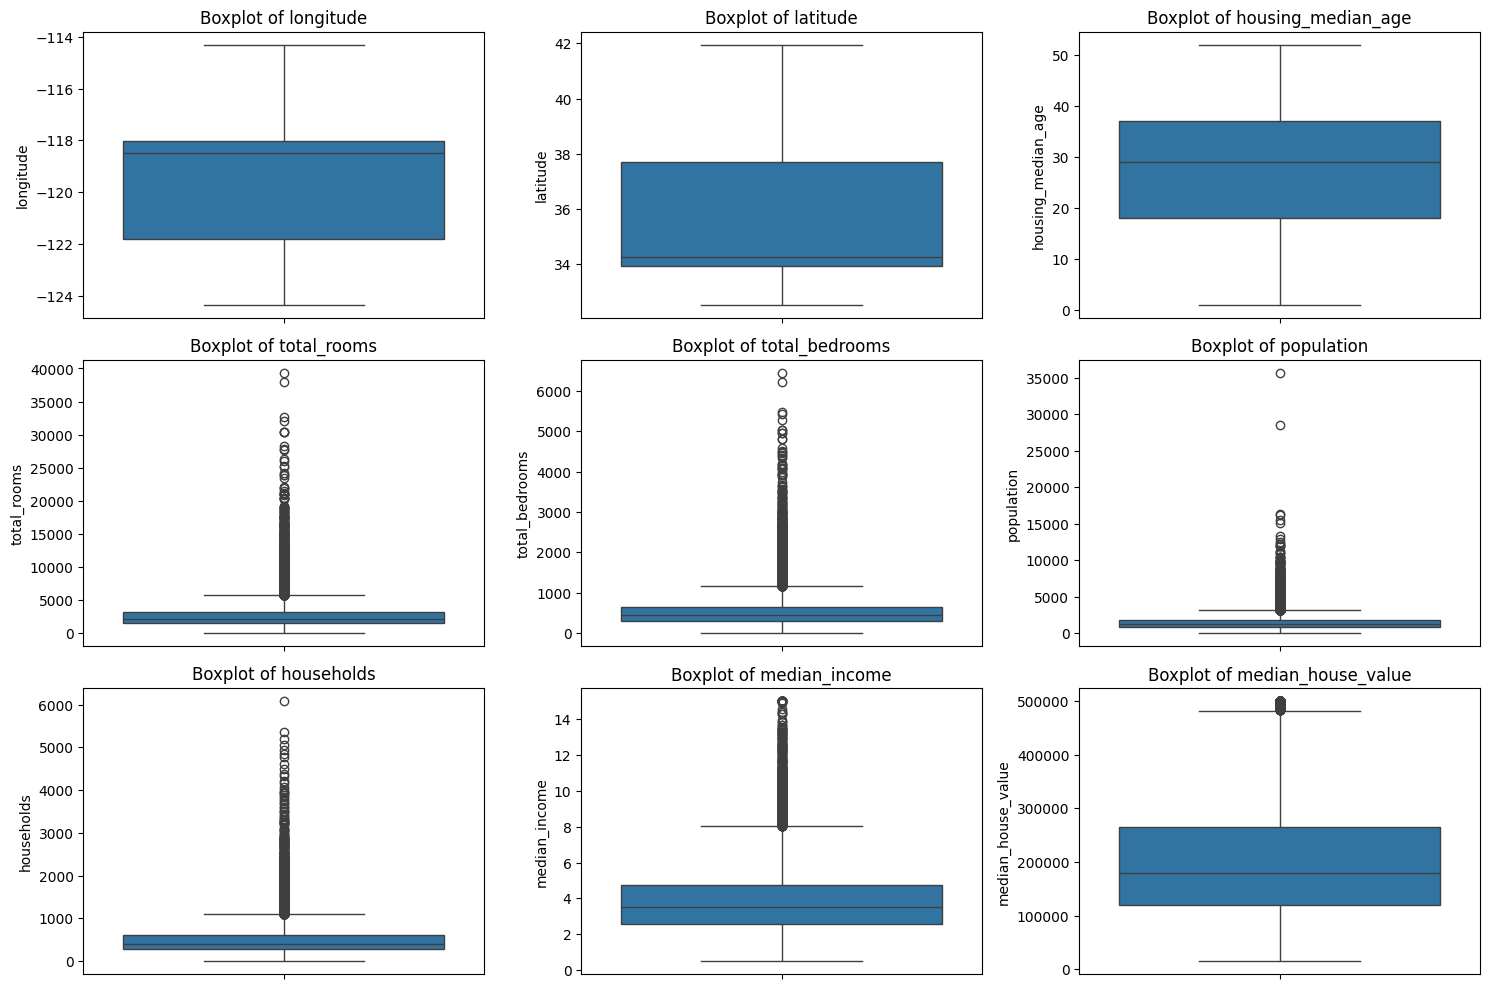

In [8]:
numerical_cols = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value' ]
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols,1):
    plt.subplot(3,3,i)
    sns.boxplot(y=housing_price[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.savefig("Housing-outliers.png")
plt.show()

In [9]:
# 1. OUTLIER CLEANING (The "Haircut")
q1 = housing_price[numerical_cols].quantile(0.25)
q3 = housing_price[numerical_cols].quantile(0.75)
IQR = q3 - q1

# Keep only the rows that are NOT outliers
housing_price = housing_price[~((housing_price[numerical_cols] < (q1 - 1.5 * IQR)) | (housing_price[numerical_cols] > (q3 + 1.5 * IQR))).any(axis=1)]

# 2. ENCODING (The "Translation")
# We do this AFTER cleaning so the rows match!
encoder = OneHotEncoder()
housing_cat = encoder.fit_transform(housing_price[['ocean_proximity']]).toarray()

# 3. ASSEMBLY (The "Glue")
features_labels = encoder.categories_[0]
feature_df = pd.DataFrame(housing_cat, columns=features_labels, index=housing_price.index)

# Combine them and drop the old text column
housing_price = pd.concat([housing_price, feature_df], axis=1)
housing_price = housing_price.drop('ocean_proximity', axis=1)

# 4. VERIFY
housing_price.info()

<class 'pandas.DataFrame'>
Index: 17609 entries, 2 to 20639
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17609 non-null  float64
 1   latitude            17609 non-null  float64
 2   housing_median_age  17609 non-null  float64
 3   total_rooms         17609 non-null  float64
 4   total_bedrooms      17609 non-null  float64
 5   population          17609 non-null  float64
 6   households          17609 non-null  float64
 7   median_income       17609 non-null  float64
 8   median_house_value  17609 non-null  float64
 9   <1H OCEAN           17609 non-null  float64
 10  INLAND              17609 non-null  float64
 11  ISLAND              17609 non-null  float64
 12  NEAR BAY            17609 non-null  float64
 13  NEAR OCEAN          17609 non-null  float64
dtypes: float64(14)
memory usage: 2.0 MB


In [10]:
#seperate inout feature and output column from the housing_price dataframe
housing = housing_price.drop("median_house_value", axis = 1)
housing_labels = housing_price['median_house_value']
print("output size (y) is", housing_labels.shape)

output size (y) is (17609,)


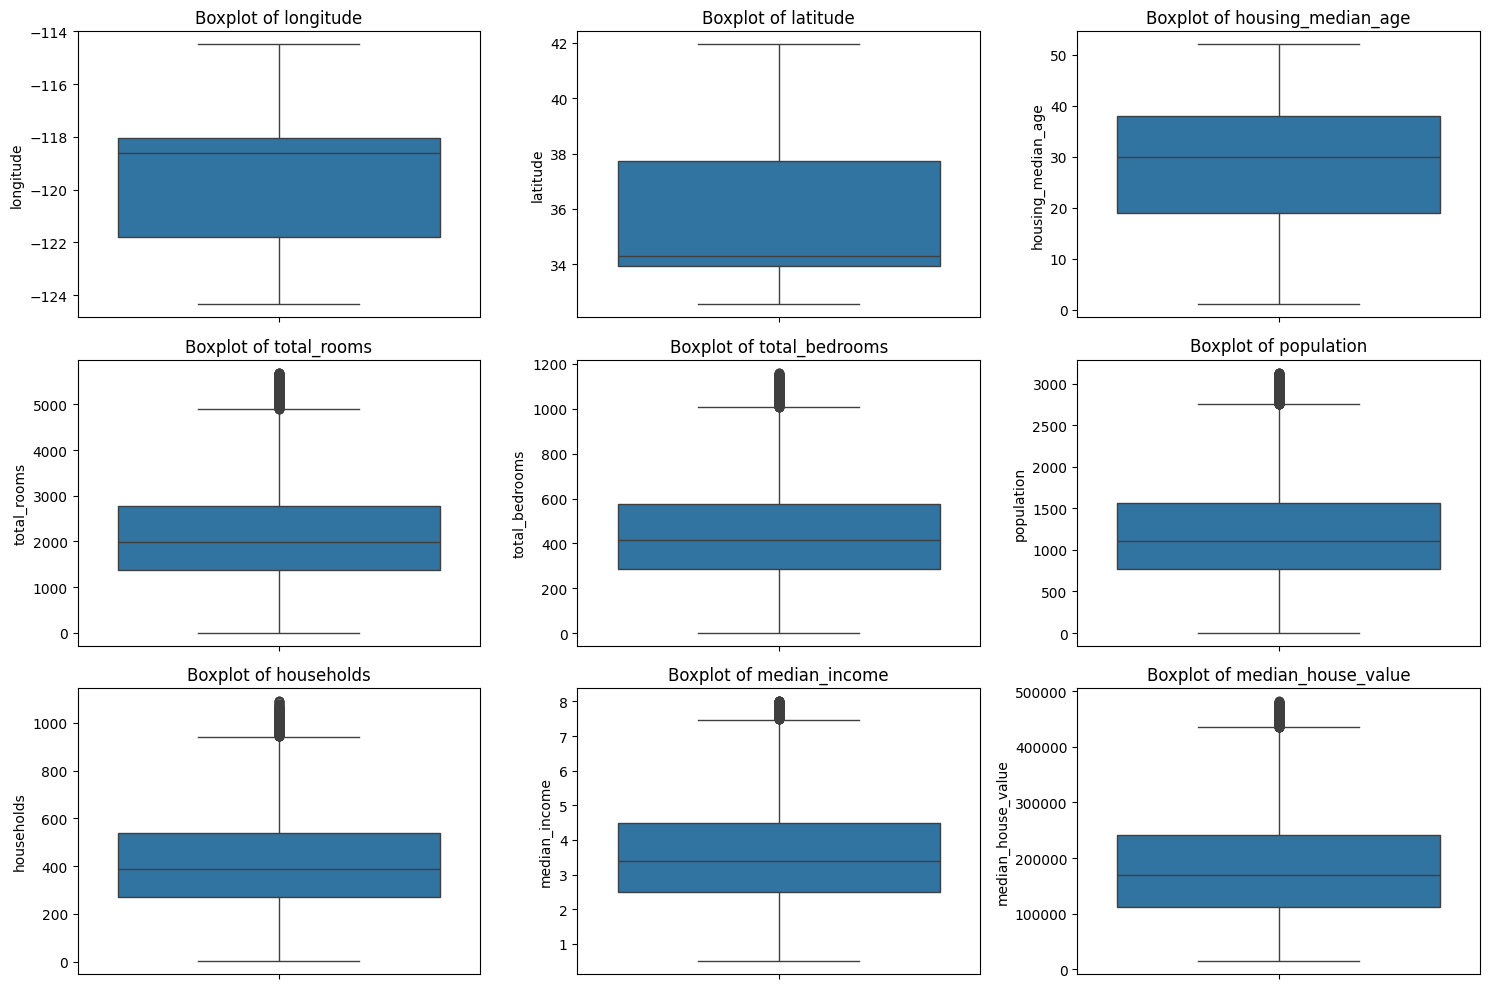

In [11]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols,1):
    plt.subplot(3,3,i)
    sns.boxplot(y=housing_price[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.savefig("Housing-outliers_after_IQR.png")
plt.show()

In [12]:
housing_price.info()

<class 'pandas.DataFrame'>
Index: 17609 entries, 2 to 20639
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17609 non-null  float64
 1   latitude            17609 non-null  float64
 2   housing_median_age  17609 non-null  float64
 3   total_rooms         17609 non-null  float64
 4   total_bedrooms      17609 non-null  float64
 5   population          17609 non-null  float64
 6   households          17609 non-null  float64
 7   median_income       17609 non-null  float64
 8   median_house_value  17609 non-null  float64
 9   <1H OCEAN           17609 non-null  float64
 10  INLAND              17609 non-null  float64
 11  ISLAND              17609 non-null  float64
 12  NEAR BAY            17609 non-null  float64
 13  NEAR OCEAN          17609 non-null  float64
dtypes: float64(14)
memory usage: 2.0 MB


In [13]:
print(f"Features (X) rows: {housing.shape[0]}")
print(f"Labels (y) rows: {housing_labels.shape[0]}")

if housing.shape[0] == housing_labels.shape[0]:
    print("✅ Match! Ready for training.")
else:
    print("❌ MISMATCH! We need to re-align the rows.")

Features (X) rows: 17609
Labels (y) rows: 17609
✅ Match! Ready for training.


In [ ]:

housing_price['age_depreciation'] = 1 - (housing_price['housing_median_age'] / 52) * 0.3
# A new house (age=1)  → multiplier ~1.0  (no penalty)
# Old house  (age=52)  → multiplier ~0.7  (30% penalty)

# Then create a value-adjusted feature
housing_price['income_age_adjusted'] = (
    housing_price['median_income'] * housing_price['age_depreciation']
)

# Preparing Data to feed to the model

In [14]:
#Dataframe housing and housing_labels
housing = housing_price.drop('median_house_value', axis=1)
housing_labels = housing_price['median_house_value']

housing_train,housing_test,housing_labels_train,housing_labels_test = train_test_split(housing,housing_labels, test_size=0.2, random_state= 42)
#we scale to get standard values
scaler = StandardScaler() #converts mean to near eqal to 0, and standard deviation to 1, it makes them comperable
housing_train_scaled = scaler.fit_transform(housing_train)#calculate the mean and standard deviation using "fit", converts x_train vakues to z-score using'transform'
housing_test_scaled = scaler.transform(housing_test)

print(housing_train_scaled[0:7])
#z-score value = normalization

[[ 0.68781924 -0.76657828 -1.35417559 -0.40549217  1.14735382  1.03059564
   1.22794314 -1.90697272  1.14824479 -0.70612819 -0.01884312 -0.35148887
  -0.37908287]
 [ 0.8620114  -0.87262722 -0.6982025  -0.50819929 -0.67190747 -0.48929747
  -0.58412382  0.91423882  1.14824479 -0.70612819 -0.01884312 -0.35148887
  -0.37908287]
 [ 1.17058038 -0.72508087  0.53174706  1.51293005  1.05160322  0.89663335
   0.81876673  0.3651104  -0.87089444  1.41617346 -0.01884312 -0.35148887
  -0.37908287]
 [ 0.81224221 -0.92334628 -1.02618905 -0.49994604  0.05762087  0.99751853
   0.07348113 -0.5472096   1.14824479 -0.70612819 -0.01884312 -0.35148887
  -0.37908287]
 [ 0.90680367 -0.9464004  -1.10818568  0.36389418  0.24000295 -0.29414253
   0.37549229  0.29565322  1.14824479 -0.70612819 -0.01884312 -0.35148887
  -0.37908287]
 [-1.1635946   0.57978216 -0.53420922  1.99803778  2.68392288  1.0653266
   2.23139957 -0.34495031 -0.87089444 -0.70612819 -0.01884312 -0.35148887
   2.63794561]
 [ 2.01665659 -1.324487

# Training the Model

In [15]:
model = LinearRegression()
model.fit(housing_train_scaled, housing_labels_train)#fit x annd y in model for training

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
housing_labels_train_pred = model.predict(housing_train_scaled)
housing_labels_test_pred = model.predict(housing_test_scaled)

In [17]:
train_rmse = np.sqrt(mean_squared_error(housing_labels_train, housing_labels_train_pred))
test_rmse = np.sqrt(mean_squared_error(housing_labels_test, housing_labels_test_pred))
train_r2 = r2_score(housing_labels_train, housing_labels_train_pred)
test_r2 = r2_score(housing_labels_test, housing_labels_test_pred)

print("\nModel Performance")
print(f"Training RMSE: {train_rmse:.2f}")#on average training value deviates by  57265.93 from actual vakue
print(f"Testing RMSE: {test_rmse:.2f}")#on average testing value deviates by 58961.43 from actual value
print(f"Training R2 Score: {train_r2:.2f}")# it is variance of training
print(f"Testing R2 Score: {test_r2:.2f}")# it is variance of testing


Model Performance
Training RMSE: 57265.93
Testing RMSE: 58961.43
Training R2 Score: 0.62
Testing R2 Score: 0.62


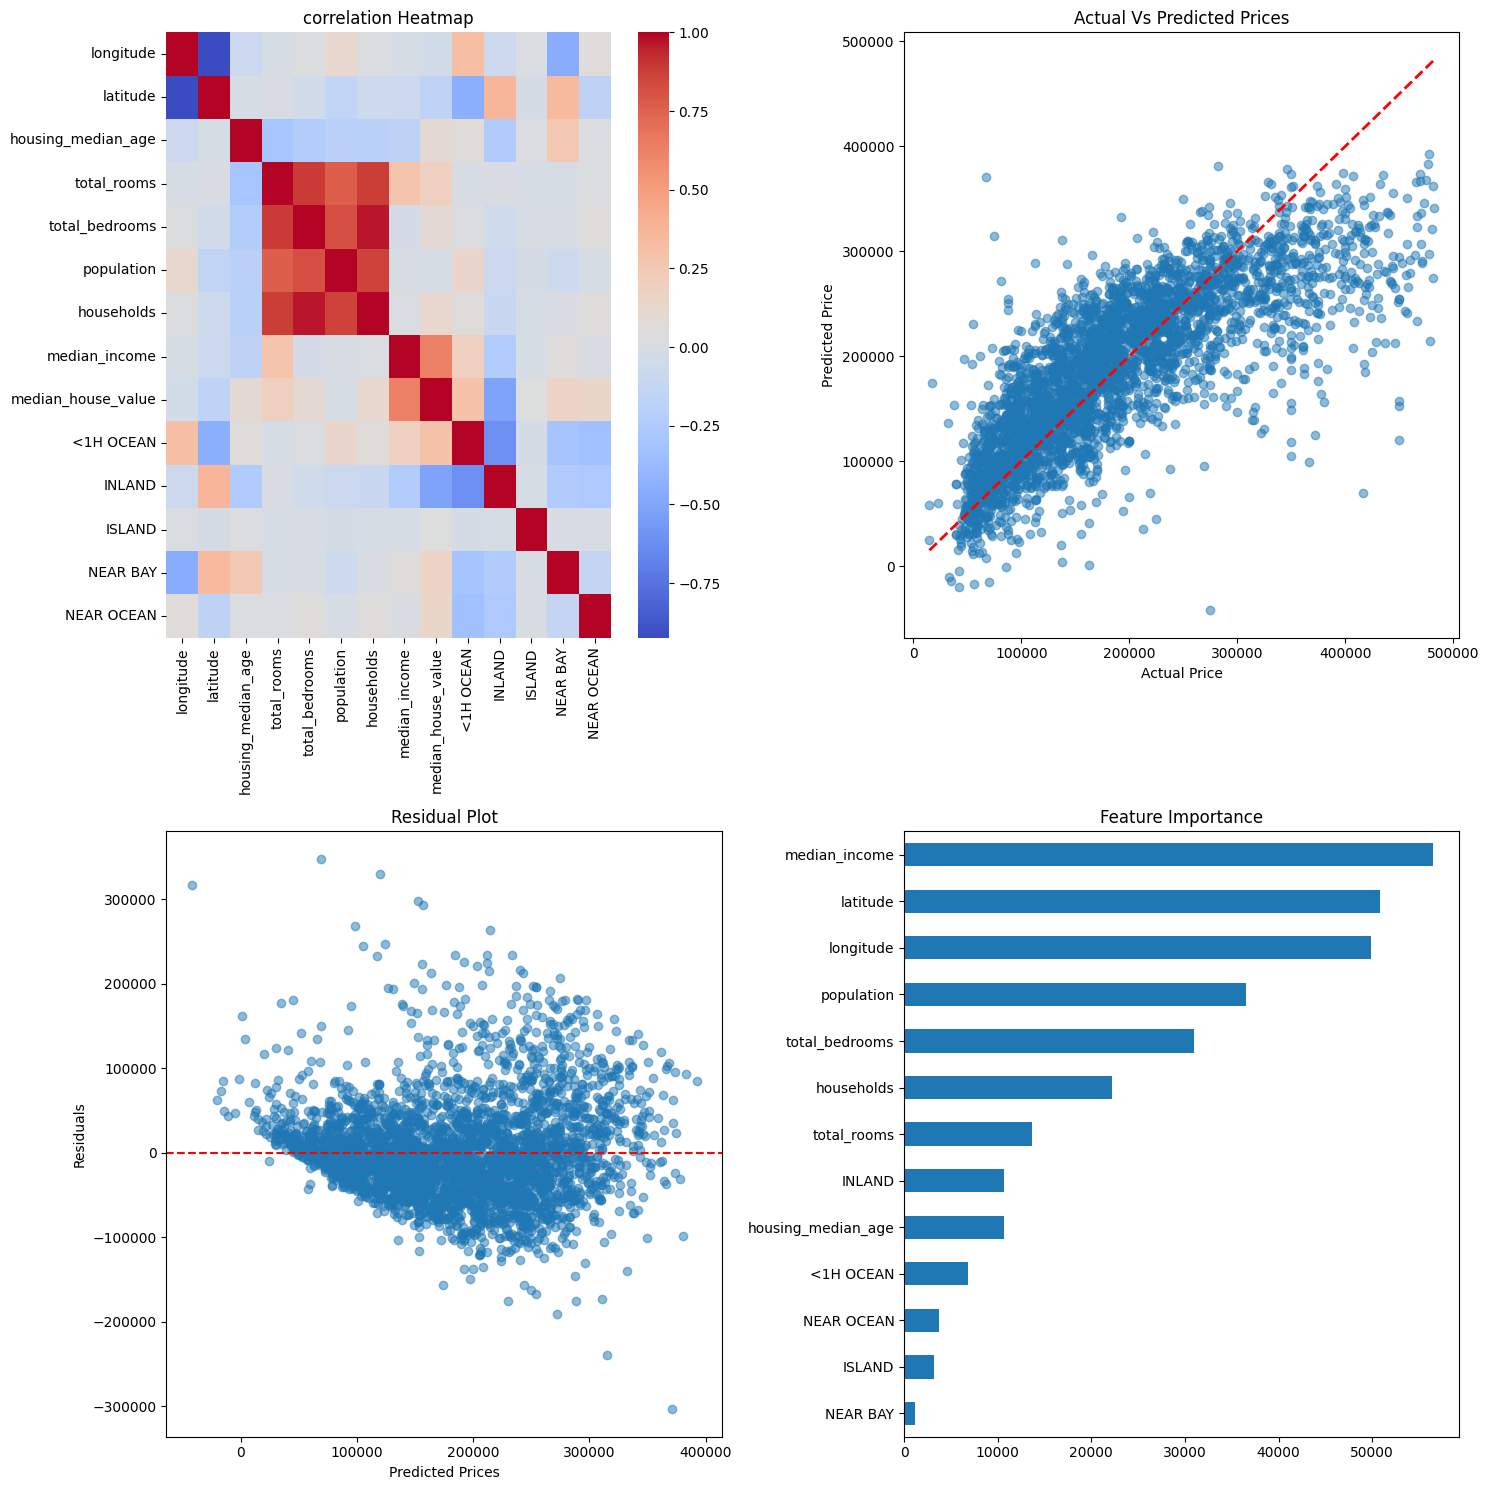

In [18]:
plt.figure(figsize = (15,15))
#correlation heatmap

plt.subplot(2,2,1)
correlation_matrix = housing_price.corr()
sns.heatmap(correlation_matrix,  annot=False, cmap='coolwarm')
plt.title('correlation Heatmap')

#scatter plot
plt.subplot(2,2,2)
plt.scatter(housing_labels_test, housing_labels_test_pred, alpha=0.5)
plt.plot([housing_labels_test.min(), housing_labels_test.max()], [housing_labels_test.min(), housing_labels_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual Vs Predicted Prices')

#Residual Scatter Plot
plt.subplot(2,2,3)
residuals = housing_labels_test - housing_labels_test_pred
plt.scatter(housing_labels_test_pred, residuals, alpha= 0.5)
plt.axhline(y=0, color = 'r', linestyle='--')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.title('Residual Plot')

#Feature Importance

plt.subplot(2,2,4)
feature_importance = pd.Series(abs(model.coef_), index= housing_price.drop('median_house_value', axis=1).columns)
feature_importance.sort_values(ascending= True).plot(kind='barh')
plt.title('Feature Importance')

plt.tight_layout()
plt.savefig("Housing_regression_plot.png")
plt.show()



In [19]:
#create a derived feature that better capture the relationship between variables
housing_price['rooms_per_household']=(
    housing_price['total_rooms']/housing_price['households']
)

housing_price['bed_rooms_per_room'] = (
    housing_price['total_bedrooms']/ housing_price['total_rooms']
)

housing_price['population_per_household']= (
    housing_price['population']/ housing_price['households']
)

In [20]:
#Regularization penalizes large coefficients, reducing overfitting. Ridges keeps all feature, lasso can zero out weak one
'''Ridge and Lasso are both regularized versions of linear regression —
they add a penalty to the loss function to prevent overfitting by discouraging large coefficients.The key difference is how they penalize.'''
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

params = {'alpha': [0.1, 1, 10, 100]}

ridge = GridSearchCV(Ridge(), params, cv=5, scoring='r2')
ridge.fit(housing_train_scaled, housing_labels_train)

print('Best alpha:', ridge.best_params_)
print('Best CV R2:', ridge.best_score_.round(4))

Best alpha: {'alpha': 1}
Best CV R2: 0.6218


In [21]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(housing_train_scaled, housing_labels_train)

rf_pred = rf.predict(housing_test_scaled)
print(f"RF R²: {r2_score(housing_labels_test, rf_pred):.4f}")
print("RF RMSE:", np.sqrt(mean_squared_error(
    housing_labels_test, rf_pred)).round(2))

RF R²: 0.7859
RF RMSE: 44257.73


In [22]:
#A K-fold cross-validation gives a more reliable estimate of model performance across different data splits.
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model, housing_train_scaled, housing_labels_train,
    cv=5, scoring='r2'
)
print(f"CV R² scores: {scores.round(4)}")
print(f"Mean R²: {scores.mean():.4f} ± {scores.std():.4f}")

CV R² scores: [0.6166 0.6094 0.6242 0.6374 0.6216]
Mean R²: 0.6218 ± 0.0093


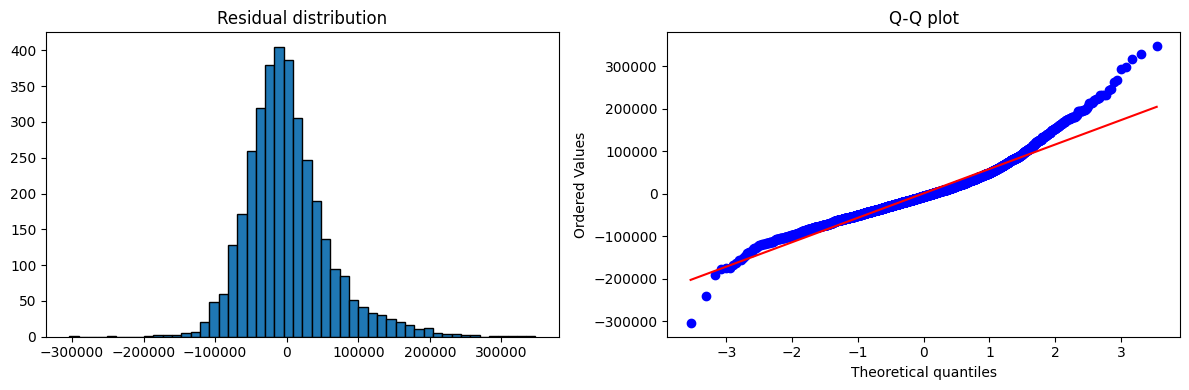

In [23]:
#Check if residuals are normally distributed — a key assumption of linear regression. A Q-Q plot and histogram reveal if the assumption holds.
import scipy.stats as stats

residuals = housing_labels_test - housing_labels_test_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals, bins=50, edgecolor='black')
axes[0].set_title('Residual distribution')

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q plot')

plt.tight_layout()
plt.savefig('residual_analysis.png')
plt.show()

In [24]:
'''Persist both the scaler and the model so you can reload them later without retraining.
Always save the scaler alongside the model — without it, new predictions will be on unscaled data.
'''
import joblib

joblib.dump(scaler, 'housing_scaler.pkl')
joblib.dump(model, 'housing_model.pkl')

# To reload later:
scaler_loaded = joblib.load('housing_scaler.pkl')
model_loaded  = joblib.load('housing_model.pkl')

# Predict on new data:
# 1. Define the exact features your scaler was trained on
features_to_use = [
    'longitude', 'latitude', 'housing_median_age', 'total_rooms',
    'total_bedrooms', 'population', 'households', 'median_income',
    '<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'
]

# 2. Filter housing_price to only include these 13 columns
# This automatically removes 'median_house_value' and the engineered features
input_data = housing_price[features_to_use]

# 3. Scale and Predict
new_data_scaled = scaler_loaded.transform(input_data)
prediction = model_loaded.predict(new_data_scaled)

print(f"Predicted price: ${prediction[0]:,.2f}")
print(f"Predicted price: ${prediction[1]:,.2f}")

Predicted price: $358,163.90
Predicted price: $304,632.21
